# Task 4: Triplet Margin Loss


In [9]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while (
    PROJECT_ROOT != PROJECT_ROOT.parent
    and not (PROJECT_ROOT / "pyproject.toml").exists()
):
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [ ]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from pytorch_metric_learning import losses
from tqdm.auto import tqdm

from src.task4.config import (
    CONFIG_DIR,
    EARLY_STOPPING_PATIENCE,
    FINAL_EPOCHS,
    HISTORY_DIR,
    IMAGE_DIR,
    INPUT_SIZE,
    LABEL_COLUMN,
    LABEL_ID_COLUMN,
    MIN_CLASS_SIZE,
    MIN_DELTA,
    MODEL_DIR,
    N_TRIALS,
    PLOT_DIR,
    SEED,
    SPLIT_DIR,
    TUNING_EPOCHS,
    VAL_FRACTION,
)
from src.task4.data import (
    make_evaluation_loader,
    make_model_loaders,
    make_validation_loss_loader,
)
from src.task4.models import ResNet18Encoder
from src.task4.preprocessing import (
    cae_transform,
    metric_eval_transform,
    metric_preprocessing_config,
    metric_train_transform,
)
from src.task4.retrieval import (
    evaluate_retrieval,
    extract_embeddings,
    k_reciprocal_rerank,
    retrieval_metrics,
    search_cosine,
)
from src.task4.training import (
    AMP_ENABLED,
    DEVICE,
    EarlyStopping,
    cpu_state_dict,
    evaluate_loss,
    new_optimizer_and_scheduler,
    set_seed,
    train_one_epoch,
)
from src.task4.tuning import create_study, suggest_parameters


## Data preparation and validation split


In [11]:
set_seed(SEED)
print("Device:", DEVICE, "| Mixed precision:", AMP_ENABLED)


Device: cuda | Mixed precision: True


In [ ]:
outer_train_df = pd.read_csv(SPLIT_DIR / "train.csv")
with (CONFIG_DIR / "articleType_gender_label_encoder.json").open(
    encoding="utf-8"
) as file:
    label_encoder_config = json.load(file)

classes = label_encoder_config["classes"]
label_to_index = label_encoder_config["label_to_index"]

outer_train_df[LABEL_COLUMN] = (
    outer_train_df["articleType"].str.strip()
    + "__"
    + outer_train_df["gender"].str.strip()
)

outer_train_df[LABEL_ID_COLUMN] = (
    outer_train_df[LABEL_COLUMN].map(label_to_index).astype("int64")
)

outer_class_counts = outer_train_df[LABEL_COLUMN].value_counts()
eligible_labels = set(outer_class_counts[outer_class_counts >= MIN_CLASS_SIZE].index)
development_df = outer_train_df[
    outer_train_df[LABEL_COLUMN].isin(eligible_labels)
].copy()


In [ ]:
inner_stratify_columns = ["articleType", "gender"]
inner_stratify_features = pd.get_dummies(
    development_df[inner_stratify_columns].astype(str),
    prefix=inner_stratify_columns,
)
inner_splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=VAL_FRACTION,
    random_state=SEED,
)
inner_train_idx, inner_val_idx = next(
    inner_splitter.split(development_df, inner_stratify_features)
)
train_df = development_df.iloc[inner_train_idx].copy()
val_df = development_df.iloc[inner_val_idx].copy()

train_counts = train_df[LABEL_ID_COLUMN].value_counts()
valid_label_ids = train_counts[train_counts >= MIN_CLASS_SIZE].index
train_df = train_df[train_df[LABEL_ID_COLUMN].isin(valid_label_ids)].copy()
val_df = val_df[val_df[LABEL_ID_COLUMN].isin(valid_label_ids)].copy()

overlap = set(train_df["id"]) & set(val_df["id"])
if overlap:
    raise ValueError(f"Inner split contains {len(overlap)} overlapping IDs")
if val_df[LABEL_ID_COLUMN].isna().any():
    raise ValueError("Inner validation contains an unmapped label")


In [14]:
gallery_parts = []
for _, group in train_df.groupby(LABEL_COLUMN, sort=True):
    sample_size = min(20, len(group))
    gallery_parts.append(group.sample(sample_size, random_state=SEED))

tuning_gallery_df = pd.concat(gallery_parts).sort_values("id").reset_index(drop=True)

print(f"Model train/validation: {len(train_df):,}/{len(val_df):,}")
print("Excluded rare rows:", len(outer_train_df) - len(development_df))
print("Tuning gallery rows:", len(tuning_gallery_df))


Model train/validation: 30,389/3,378
Excluded rare rows: 153
Tuning gallery rows: 2861


## Hyperparameter tuning


In [15]:
def triplet_objective(trial: optuna.Trial):
    parameters = suggest_parameters(trial, "triplet")
    set_seed(SEED)
    model = ResNet18Encoder()
    loss_function = losses.TripletMarginLoss(margin=parameters.get("margin", 0.3))
    model, loss_function = model.to(DEVICE), loss_function.to(DEVICE)
    loaders = make_model_loaders(
        "triplet",
        train_df,
        tuning_gallery_df,
        val_df,
        cae_transform,
        metric_train_transform,
        metric_eval_transform,
        IMAGE_DIR,
    )
    optimizer, scheduler = new_optimizer_and_scheduler(model, parameters)
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    best_score = -math.inf
    for epoch in tqdm(range(1, TUNING_EPOCHS + 1), desc="triplet tuning"):
        train_one_epoch(
            "triplet", model, loss_function, loaders["train"], optimizer, scaler, epoch
        )
        score = evaluate_retrieval(model, loaders["gallery"], loaders["query"])[
            "mAP@10"
        ]
        scheduler.step(score)
        best_score = max(best_score, score)
        trial.report(score, step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return best_score

In [16]:
triplet_study = create_study("task4_triplet")
triplet_study.optimize(triplet_objective, n_trials=N_TRIALS)
triplet_best_params = dict(triplet_study.best_params)
print("triplet", "best parameters:", triplet_best_params)

[I 2026-09-06 16:53:18,973] Using an existing study with name 'task4_triplet' instead of creating a new one.


triplet tuning:   0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-06 16:58:33,137] Trial 1 finished with value: 0.1977120317898885 and parameters: {'learning_rate': 8.468008575248323e-05, 'weight_decay': 0.0007114476009343421, 'margin': 0.8}. Best is trial 1 with value: 0.1977120317898885.


triplet tuning:   0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-06 17:03:55,621] Trial 2 finished with value: 0.3694271171069573 and parameters: {'learning_rate': 0.00030405325392865646, 'weight_decay': 2.9380279387035354e-06, 'margin': 0.2}. Best is trial 2 with value: 0.3694271171069573.


...

triplet tuning:   0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-06 18:13:56,216] Trial 19 pruned. 


triplet tuning:   0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-06 18:14:57,778] Trial 20 pruned. 


triplet best parameters: {'learning_rate': 0.00018785426399210597, 'weight_decay': 5.987474910461405e-05, 'margin': 0.1}


## Final training


In [17]:
triplet_history = []
triplet_best_epoch = 0
triplet_best_score = -math.inf

parameters = triplet_best_params
set_seed(SEED)
model = ResNet18Encoder()
loss_function = losses.TripletMarginLoss(margin=parameters.get("margin", 0.3))
model, loss_function = model.to(DEVICE), loss_function.to(DEVICE)
loaders = make_model_loaders(
    "triplet",
    train_df,
    tuning_gallery_df,
    val_df,
    cae_transform,
    metric_train_transform,
    metric_eval_transform,
    IMAGE_DIR,
)
val_loss_loader = make_validation_loss_loader(
    "triplet", val_df, cae_transform, metric_eval_transform, IMAGE_DIR
)


In [18]:
optimizer, scheduler = new_optimizer_and_scheduler(model, parameters)
scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
stopper = EarlyStopping(EARLY_STOPPING_PATIENCE, MIN_DELTA)
best_state = None


In [19]:
for epoch in tqdm(range(1, FINAL_EPOCHS + 1), desc="triplet final"):
    train_loss = train_one_epoch(
        "triplet", model, loss_function, loaders["train"], optimizer, scaler, epoch
    )
    val_loss = evaluate_loss("triplet", model, loss_function, val_loss_loader)
    metrics = evaluate_retrieval(model, loaders["gallery"], loaders["query"])
    score = metrics["mAP@10"]
    scheduler.step(score)
    if stopper.update(score):
        best_state = cpu_state_dict(model)
        triplet_best_epoch = epoch
    triplet_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_map_at_10": score,
        }
    )
    print("triplet", epoch, "loss:", round(train_loss, 4), "mAP@10:", round(score, 4))
    if stopper.should_stop:
        break


triplet final:   0%|          | 0/60 [00:00<?, ?it/s]

triplet 1 loss: 0.101 mAP@10: 0.1791
triplet 2 loss: 0.0972 mAP@10: 0.2131
triplet 3 loss: 0.0959 mAP@10: 0.2354
triplet 4 loss: 0.0954 mAP@10: 0.2481
triplet 5 loss: 0.0956 mAP@10: 0.263
triplet 6 loss: 0.0946 mAP@10: 0.2762
triplet 7 loss: 0.0936 mAP@10: 0.28
triplet 8 loss: 0.0945 mAP@10: 0.2957
triplet 9 loss: 0.094 mAP@10: 0.3184
triplet 10 loss: 0.0944 mAP@10: 0.3242
triplet 11 loss: 0.0926 mAP@10: 0.3425
triplet 12 loss: 0.0934 mAP@10: 0.345
triplet 13 loss: 0.0925 mAP@10: 0.3558
triplet 14 loss: 0.0933 mAP@10: 0.3775
triplet 15 loss: 0.0909 mAP@10: 0.3791
triplet 16 loss: 0.0921 mAP@10: 0.3633
triplet 17 loss: 0.0915 mAP@10: 0.3918
triplet 18 loss: 0.0931 mAP@10: 0.3875
triplet 19 loss: 0.0917 mAP@10: 0.3889
triplet 20 loss: 0.0897 mAP@10: 0.4001
triplet 21 loss: 0.0913 mAP@10: 0.4084
triplet 22 loss: 0.0911 mAP@10: 0.4123
triplet 23 loss: 0.0908 mAP@10: 0.4283
triplet 24 loss: 0.0928 mAP@10: 0.4196
triplet 25 loss: 0.0914 mAP@10: 0.4297
triplet 26 loss: 0.0924 mAP@10: 0.4256
t

In [20]:
model.load_state_dict(best_state)
triplet_best_score = stopper.best_score
triplet_model = model
print("triplet", "best epoch:", triplet_best_epoch, "best mAP@10:", triplet_best_score)


triplet best epoch: 60 best mAP@10: 0.5679351648231162


## Training history and learning curves


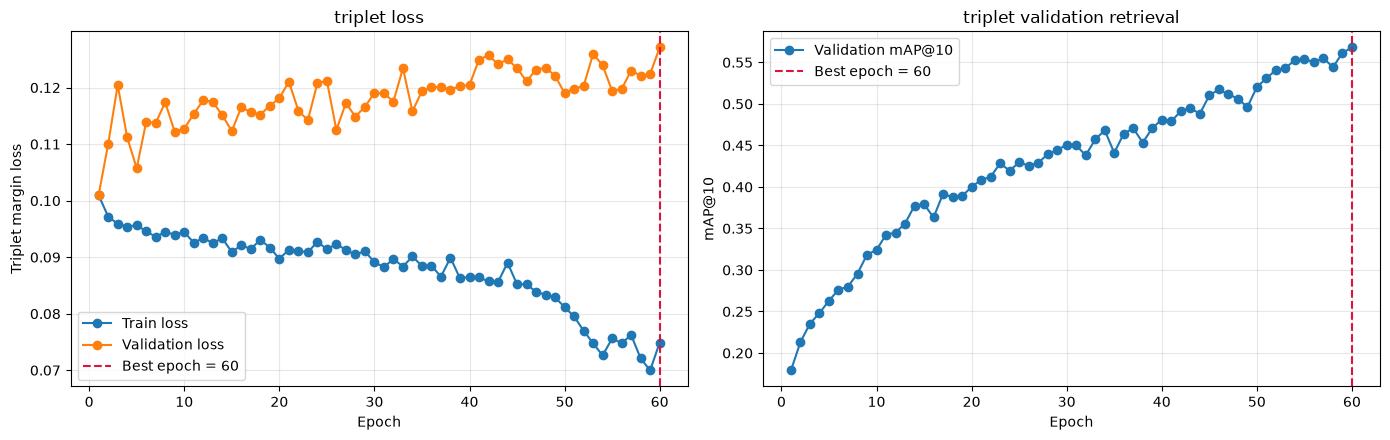

In [21]:
HISTORY_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

history_path = HISTORY_DIR / "triplet_history.csv"
pd.DataFrame(triplet_history).sort_values("epoch").to_csv(history_path, index=False)
history_df = pd.read_csv(history_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(
    history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss"
)
axes[0].plot(
    history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss"
)
axes[0].axvline(
    triplet_best_epoch,
    color="crimson",
    linestyle="--",
    label=f"Best epoch = {triplet_best_epoch}",
)
axes[0].set_title("triplet loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Triplet margin loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_df["epoch"],
    history_df["val_map_at_10"],
    marker="o",
    label="Validation mAP@10",
)
axes[1].axvline(
    triplet_best_epoch,
    color="crimson",
    linestyle="--",
    label=f"Best epoch = {triplet_best_epoch}",
)
axes[1].set_title("triplet validation retrieval")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP@10")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(PLOT_DIR / "triplet_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## Save model and evaluate retrieval


In [29]:
model_directory = MODEL_DIR / "triplet"
model_directory.mkdir(parents=True, exist_ok=True)
checkpoint = {
    "model_name": "triplet",
    "model_state_dict": cpu_state_dict(triplet_model),
    "model_config": {
        "backbone": "resnet18",
        "pretrained": False,
        "input_size": list(INPUT_SIZE),
        "embedding_dimension": 512,
        "class_count": len(classes),
    },
    "best_params": triplet_best_params,
    "best_epoch": triplet_best_epoch,
    "best_val_map_at_10": triplet_best_score,
    "preprocessing_config": metric_preprocessing_config,
    "label_to_index": label_to_index,
    "gallery_scope": "eligible_inner_training",
    "random_seed": SEED,
}
torch.save(checkpoint, model_directory / "best.pt")
print("Saved:", model_directory / "best.pt")


Saved: /workspace/Machine-Learning-Assignment-2/artifacts/task4/models/triplet/best.pt


In [30]:
gallery_loader = make_evaluation_loader(
    "triplet", train_df, cae_transform, metric_eval_transform, IMAGE_DIR
)
gallery_embeddings, gallery_ids, gallery_labels = extract_embeddings(
    triplet_model, gallery_loader
)
np.save(model_directory / "gallery_embeddings.npy", gallery_embeddings)
np.save(model_directory / "gallery_ids.npy", gallery_ids)


In [31]:
query_loader = make_evaluation_loader(
    "triplet", val_df, cae_transform, metric_eval_transform, IMAGE_DIR
)
query_embeddings, _, query_labels = extract_embeddings(triplet_model, query_loader)


In [32]:
_, base_indices, index = search_cosine(query_embeddings, gallery_embeddings)
reranked_indices = k_reciprocal_rerank(query_embeddings, gallery_embeddings, index)
print("triplet", "base:", retrieval_metrics(base_indices, query_labels, gallery_labels))
print(
    "triplet",
    "reranked:",
    retrieval_metrics(reranked_indices, query_labels, gallery_labels),
)

triplet base: {'Precision@1': 0.7812314979277679, 'Recall@1': 0.0033985245364074566, 'Precision@5': 0.7628774422735346, 'Recall@5': 0.016427438973389056, 'Precision@10': 0.7539076376554174, 'Recall@10': 0.031375358657626945, 'mAP@10': 0.6969926751372874}
triplet reranked: {'Precision@1': 0.7554766133806986, 'Recall@1': 0.0033407676404398675, 'Precision@5': 0.7515689757252811, 'Recall@5': 0.016204912375693936, 'Precision@10': 0.7481053878034339, 'Recall@10': 0.03146920279364254, 'mAP@10': 0.6932814364891406}
